In [14]:
import pandas as pd
import os

In [15]:
os.chdir('C:/Users/basleal/Desktop/tutorial/kaim-week-10')

In [19]:
oil_price=pd.read_csv('data/BrentOilPrices.csv')
wb_gdp=pd.read_csv('data/wb_gdp.csv')
merged_data= pd.read_csv('data/merged_data.csv')
merged_data.drop(columns='Unnamed: 0')


,Unnamed: 0.1,country,Date,GDP,Year,Price
0,0,Africa Eastern and Southern,2022-01-01 01:00:00-01:00,1.191423e+12,2022,103.477545
1,1,Africa Eastern and Southern,2021-01-01 01:00:00-01:00,1.085745e+12,2021,70.855336
2,2,Africa Eastern and Southern,2020-01-01 01:00:00-01:00,9.333918e+11,2020,42.101016
3,3,Africa Eastern and Southern,2019-01-01 01:00:00-01:00,1.009721e+12,2019,64.319845
4,4,Africa Eastern and Southern,2018-01-01 01:00:00-01:00,1.012306e+12,2018,71.335000
...,...,...,...,...,...,...
9571,9571,Zimbabwe,1991-01-01 01:00:00-01:00,8.641482e+09,1991,20.041128
9572,9572,Zimbabwe,1990-01-01 01:00:00-01:00,8.783817e+09,1990,23.761445
9573,9573,Zimbabwe,1989-01-01 01:00:00-01:00,8.286323e+09,1989,18.228228
9574,9574,Zimbabwe,1988-01-01 01:00:00-01:00,7.814784e+09,1988,14.905412


In [20]:
merged_data=merged_data.dropna()

merged_data = merged_data.drop_duplicates()
merged_data.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
country         0
Date            0
GDP             0
Year            0
Price           0
dtype: int64

Analyze Economic Factors & Oil Prices

In [21]:
cor_matrix=merged_data[['GDP','Price']].corr()
print(cor_matrix)

            GDP     Price
GDP    1.000000  0.100506
Price  0.100506  1.000000


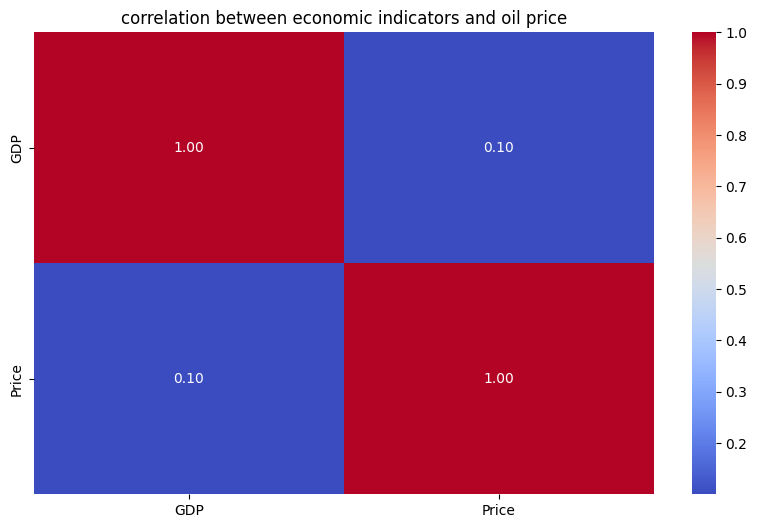

In [22]:
#visualize correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cor_matrix,annot=True,cmap="coolwarm",fmt='.2f')
plt.title('correlation between economic indicators and oil price')
plt.show()

let's plot a scatter plot now

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

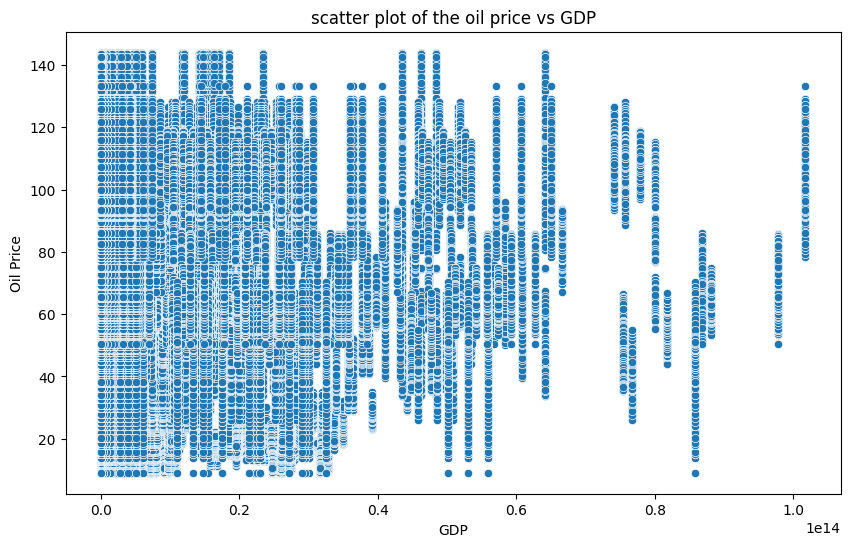

In [7]:
#visualizing
plt.figure(figsize=(10,6))
sns.scatterplot(x='GDP',y='Price',data=merged_data)
plt.title('scatter plot of the oil price vs GDP')
plt.xlabel('GDP')
plt.ylabel('Oil Price')
plt.show()

line plot

c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


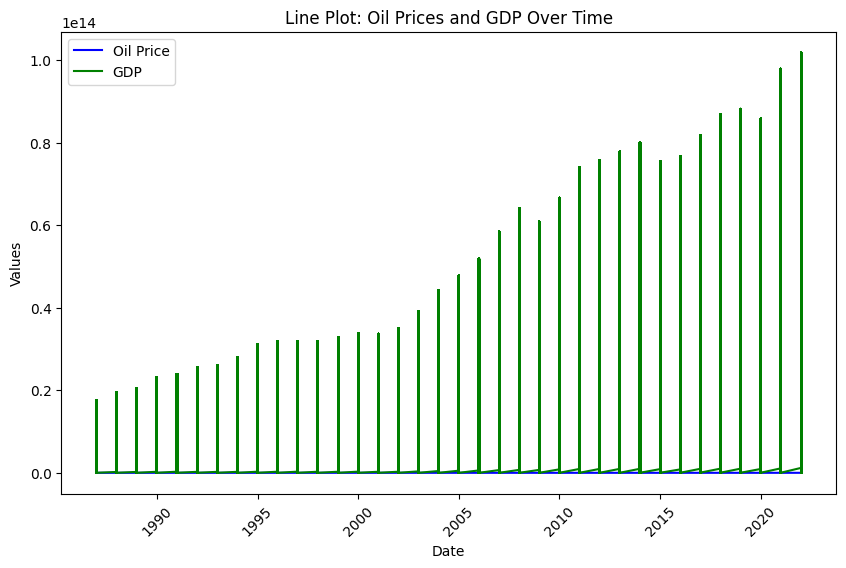

In [8]:
#plotting oil prices vs GDP over time
plt.figure(figsize=(10,6))
plt.plot(merged_data['Date'],merged_data['Price'],label='Oil Price',color='blue')
plt.plot(merged_data['Date'],merged_data['GDP'],label='GDP',color = 'green')
plt.title('Line Plot: Oil Prices and GDP Over Time')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.show()

now let's build models

1. Vector Autoregression (VAR)

In [23]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
#check for stationary(ADF test)
adf_test_oil=adfuller(merged_data['Price'].dropna())
adf_test_gdp=adfuller(merged_data['GDP'].dropna())
#if they are non-stationary, we might need to difference them
merged_data_diff=merged_data[['Price','GDP']].diff().dropna()
#select the lag length using AIC or BIC
model=VAR(merged_data_diff)
lag_order=model.select_order().aic
#fit the model
var_model = model.fit(lag_order)
var_model.summary()


c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 25, Feb, 2025
Time:                     18:48:51
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    61.3086
Nobs:                     9013.00    HQIC:                   61.2306
Log likelihood:          -301182.    FPE:                3.75511e+26
AIC:                      61.1903    Det(Omega_mle):     3.69338e+26
--------------------------------------------------------------------
Results for equation Price
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const            -0.000253         0.110335           -0.002           0.998
L1.Price         -0.192377         0.010557          -18.223           0.000
L1.GDP           -0.000000         0.000000           -4.191           0.000

2.markov-switching ARIMA Models

In [24]:
from statsmodels.tsa.regime_switching import markov_autoregression
from statsmodels.tsa.arima.model import ARIMA

#fit an ARIMA model
arima_model = ARIMA(merged_data['Price'],order=(1,1,1))
arima_fitted = arima_model.fit()


c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [25]:
print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 9051
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -40342.181
Date:                Tue, 25 Feb 2025   AIC                          80690.362
Time:                        18:49:04   BIC                          80711.694
Sample:                             0   HQIC                         80697.619
                               - 9051                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4633      0.035     13.137      0.000       0.394       0.532
ma.L1         -0.6741      0.031    -21.811      0.000      -0.735      -0.613
sigma2       435.9268      3.392    128.517      0.0

now let's try the lstm model

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [27]:
#normalize our data
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data= scaler.fit_transform(merged_data[['Price']].values)

In [ ]:
#prepare the data for lstm(create sequences)
import numpy as np
def create_sequence(data, seq_length=60):
    X,y=[],[]
    for i in range(seq_length,len(data)):
        X.append(data[i-seq_length:i,0])
        y.append(data[i,0])
    return np.array(X), np.array(y)
X,y = create_sequence(scaled_data)
#Reshape data for LSTM input (Samples, time steps, features)
X = X.reshape((X.shape[0],X.shape[1],1))
#split the data into train and test
train_size = int(len(X)*0.8)
X_train,X_test = X[:train_size], X[:train_size:]
y_train, y_test = y[:train_size], y[train_size:]
#define the lstm model
model=Sequential()
model.add(LSTM(units=50,return_sequences=True,input_shape=(X_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))

# Compile and fit the model
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Make predictions
predictions = model.predict(X_test)

# Inverse scaling to get original values
predicted_prices = scaler.inverse_transform(predictions)

c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - loss: 0.0848
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - loss: 0.0373
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0346
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0268
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0228
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0192
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.0175
Epoch 8/10
 20/225 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 0.0125

backtesting and evaluation


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#evaluate model on test data (for lstm)
y_pred=model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
#print results
print(f'RMSE: {rmse}, MAE: {mae}, R2: {r2}')